In [1]:
import shap
import joblib
import os
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

# XGBoost model 

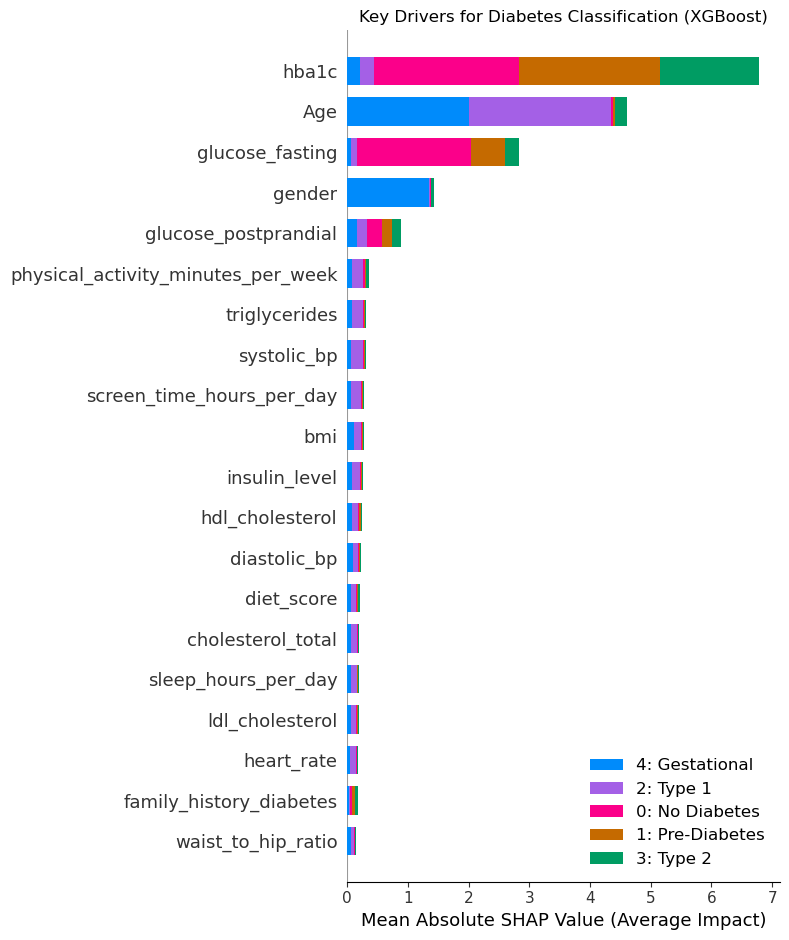

In [4]:
xgb_model = joblib.load('../artifacts/xgboost_model.pkl')

X_test_unscaled = pd.read_csv('../data/processed/X_test.csv')

feature_order = xgb_model.feature_names_in_
X_test_unscaled = X_test_unscaled[feature_order]

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_unscaled)

target_names = [
    '0: No Diabetes', 
    '1: Pre-Diabetes', 
    '2: Type 1', 
    '3: Type 2', 
    '4: Gestational'
]

shap.summary_plot(
    shap_values, 
    X_test_unscaled,  
    class_names=target_names, 
    plot_type="bar", 
    show=False
)

plt.title("Key Drivers for Diabetes Classification (XGBoost)")
plt.xlabel("Mean Absolute SHAP Value (Average Impact)")
plt.tight_layout()
plt.show()

## XGBoost Model: Global Feature Importance Graph

The SHAP bar plot above displays feature importance for the XGBoost diabetes classification model.

### Key Findings

| Rank | Feature | Clinical Relevance |
|------|---------|-------------------|
| 1 | **HbA1c** | Dominant predictor—gold standard clinical marker for diabetes |
| 2 | **Age** | Well-established risk factor for metabolic dysfunction |
| 3 | **glucose_fasting** | Standard screening marker for diabetes |
| 4 | **gender** | Biological sex influences metabolic risk |
| 5 | **glucose_postprandial** | Post-meal glucose provides additional signal |

### Clinical Validation

The model learned the correct clinical hierarchy: HbA1c and glucose metrics dominate predictions, while lifestyle factors and secondary markers contribute appropriately.

# K-Means model

Validation accuracy: 75.5%

SHAP values type: <class 'numpy.ndarray'>
Shape: (1000, 19, 3)


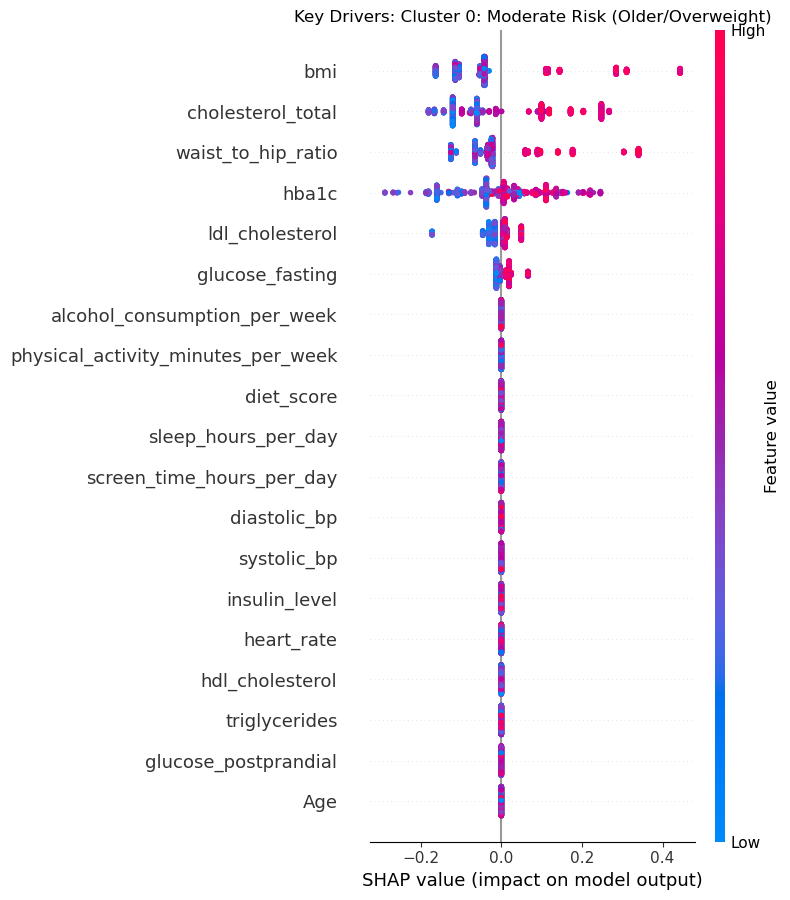

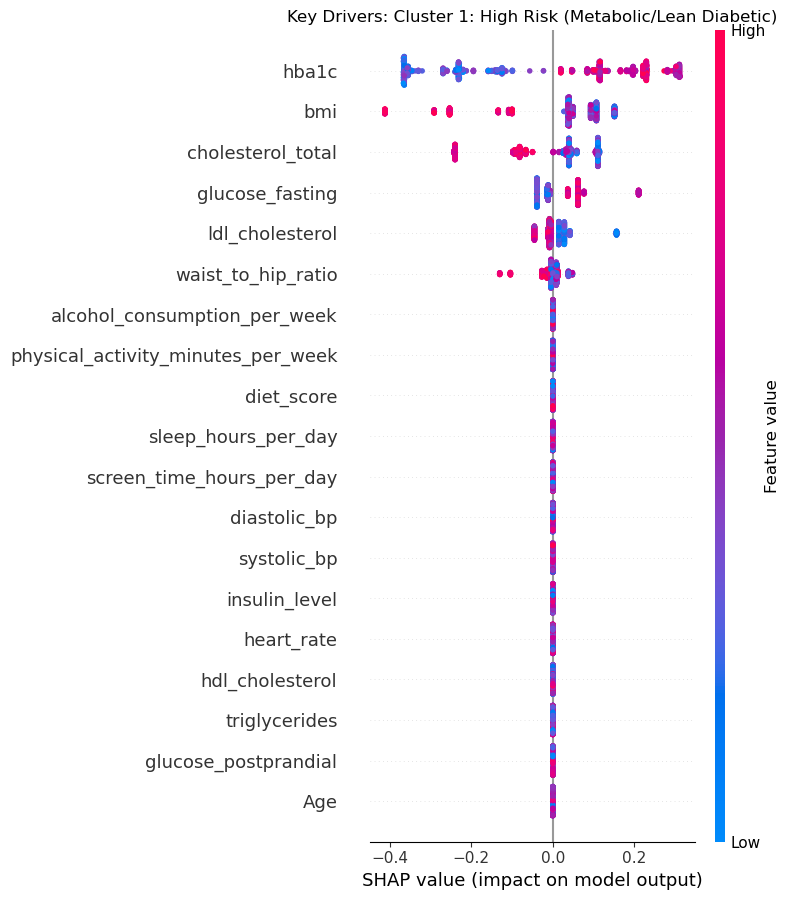

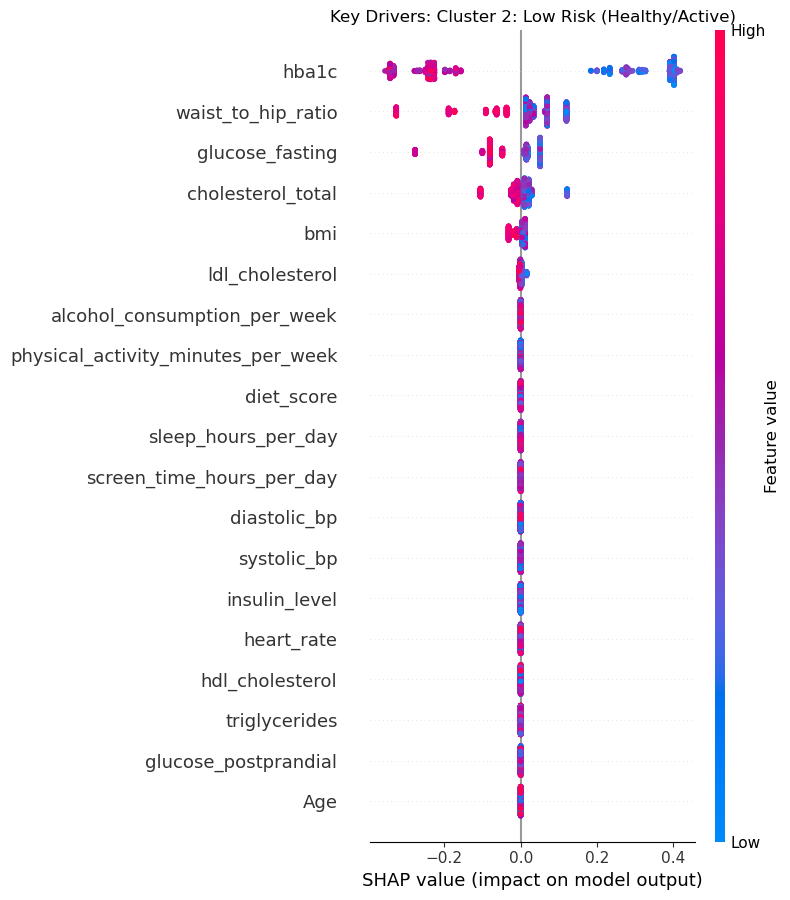

In [20]:
import shap
import matplotlib.pyplot as plt
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

clinical_features = [
    'Age', 'alcohol_consumption_per_week', 'physical_activity_minutes_per_week', 
    'diet_score', 'sleep_hours_per_day', 'screen_time_hours_per_day', 'bmi', 
    'waist_to_hip_ratio', 'systolic_bp', 'diastolic_bp', 'heart_rate', 
    'cholesterol_total', 'hdl_cholesterol', 'ldl_cholesterol', 'triglycerides', 
    'glucose_fasting', 'glucose_postprandial', 'insulin_level', 'hba1c'
]

X_sample = X_test_scaled[clinical_features].sample(n=1000, random_state=42)
cluster_sample = kmeans_model.predict(X_sample)

X_train, X_val, y_train, y_val = train_test_split(
    X_sample, cluster_sample, test_size=0.2, random_state=42, stratify=cluster_sample
)

surrogate = DecisionTreeClassifier(
    max_depth=3,
    min_samples_split=50,
    min_samples_leaf=25,
    random_state=42
)
surrogate.fit(X_train, y_train)

print(f"Validation accuracy: {surrogate.score(X_val, y_val):.1%}")

explainer = shap.TreeExplainer(surrogate)
shap_values_raw = explainer.shap_values(X_sample)

print(f"\nSHAP values type: {type(shap_values_raw)}")
if isinstance(shap_values_raw, list):
    print(f"List length: {len(shap_values_raw)}")
    print(f"Shape of class 0: {shap_values_raw[0].shape}")
else:
    print(f"Shape: {shap_values_raw.shape}")

if isinstance(shap_values_raw, list):
    shap_values = shap_values_raw

elif len(shap_values_raw.shape) == 3:
    shap_values = [shap_values_raw[:, :, i] for i in range(shap_values_raw.shape[2])]

else:
    shap_values = [shap_values_raw]

cluster_names = {
    0: "Cluster 0: Moderate Risk (Older/Overweight)",
    1: "Cluster 1: High Risk (Metabolic/Lean Diabetic)",
    2: "Cluster 2: Low Risk (Healthy/Active)"
}

for cluster_idx in range(3):
    plt.figure(figsize=(10, 6))
    
    sv_cluster = shap_values[cluster_idx]

    n_samples = min(sv_cluster.shape[0], X_sample.shape[0])
    
    shap.summary_plot(
        sv_cluster[:n_samples],
        X_sample.iloc[:n_samples],
        feature_names=clinical_features,
        show=False
    )
    
    plt.title(f"Key Drivers: {cluster_names[cluster_idx]}")
    plt.tight_layout()
    plt.show()

# Patient Segment Profiles

## Cluster 0: Senior / Lifestyle-Driven Segment
- **Statistical Core**: Includes approximately 22,900 patients (~34% of the sample), making this the largest segment.

- **Clinical Profile**: The oldest segment (avg. age 57) with the highest average BMI (28.3), elevated waist-to-hip ratio, and moderately elevated glucose (115 mg/dL fasting, HbA1c 6.73%).

- **SHAP Driver Insight**: SHAP analysis confirms that **BMI and cholesterol markers** are the primary differentiators for this group. The beeswarm plot shows that patients are assigned to this cluster based on body composition and lipid profiles rather than extreme glycemic dysfunction.

- **Practical Context**: This group represents **"Age-Related Metabolic Risk"**—patients whose primary risk factors stem from aging, increased adiposity, and lifestyle factors. Interventions targeting weight management, physical activity, and cholesterol control are likely to yield the highest impact for this population.

## Cluster 1: High-Risk Metabolic Segment (Lean Diabetic Profile)
- **Statistical Core**: Comprises approximately 20,500 patients (~31% of the sample).

- **Clinical Profile**: Exhibits the **highest clinical risk** in the dataset, with a mean HbA1c of **7.09%** (diabetic range) and Fasting Glucose of **118 mg/dL**, despite having a **normal average BMI of 24.1**.

- **SHAP Driver Insight**: SHAP analysis identifies **HbA1c and glucose markers** as the dominant predictors for this group. Notably, high values of these features strongly push patients INTO this cluster, while high BMI pushes patients AWAY. This confirms the model recognizes a distinct "lean diabetic" or "metabolically unhealthy normal-weight" phenotype.

- **Practical Context**: These patients represent the **highest-priority clinical cases**—individuals whose glycemic dysfunction is severe despite normal body weight. They may be missed by traditional BMI-based screening but require urgent medical intervention. This group demonstrates that metabolic health can deteriorate independent of obesity.

## Cluster 2: Baseline / Low-Risk Segment
- **Statistical Core**: Represents the healthiest segment of the sample with an average age of 44.

- **Clinical Profile**: Characterized by the **lowest metabolic markers**, maintaining a mean HbA1c of **5.8%** (normal range) and Fasting Glucose of **100 mg/dL** (normal range). BMI averages 24.3 (upper-normal range).

- **SHAP Driver Insight**: SHAP analysis shows that **low glucose and low HbA1c** are the primary inclusive drivers for this group (appearing as blue on the right side of the beeswarm). Patients are assigned here based on the **absence** of elevated metabolic risk markers.

- **Practical Context**: This group serves as the **"Control" or "Healthy Reference" segment**, representing younger individuals with stable metabolic health. Prevention and maintenance strategies are most appropriate for this population.

---


## Key Clinical Insight

The model successfully identified two distinct high-risk phenotypes:
1. **Cluster 0**: Traditional age/BMI-driven risk (visible, screenable)
2. **Cluster 1**: Metabolic dysfunction despite normal BMI (hidden, easily missed)

This demonstrates the model's ability to detect clinically meaningful patterns beyond simple BMI-based stratification.